<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week3/Week_3_Assignment_Nikolai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Visualization + Linear Regression (R → Python Bridge)**
## **Nikolai Navarro**
---




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily
...,...,...,...,...,...,...
595,100596,232811.0,1443.241197,3.0,Midtown,Condo
596,100597,235624.0,1083.909714,2.0,Suburb,Condo
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo


---
## Part I -- Visualization (40 pts)
## A. Scatterplots and Aesthetics

1. Create a scatterplot of size vs price.

    - Label axes clearly.
    - Add a meaningful title.
2. Recreate the plot using color = neighborhood (use seaborn).

3. Use transparency (alpha) to reduce overplotting.


Text(0, 0.5, 'Price ($)')

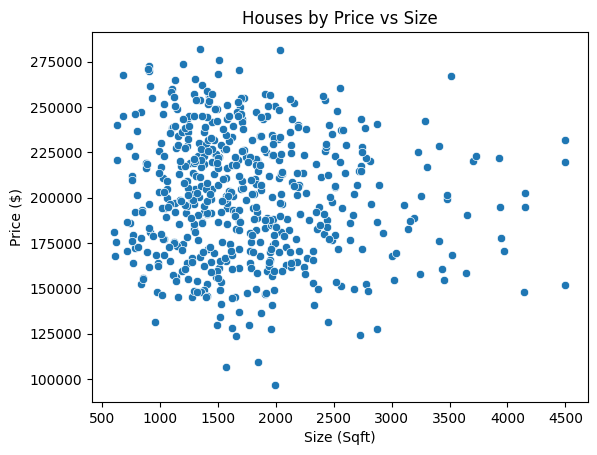

In [ ]:
sns.scatterplot(data= df, x= "size", y= "price")
plt.title("Houses by Price vs Size")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

Text(0, 0.5, 'Price ($)')

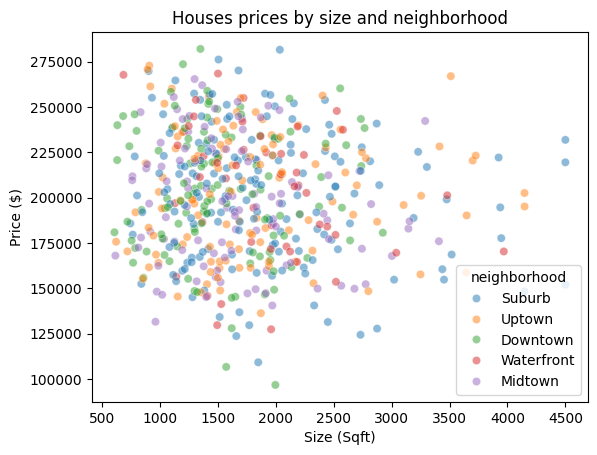

In [ ]:
sns.scatterplot(data= df, x= "size", y= "price", hue= "neighborhood", alpha= 0.5)
plt.title("Houses prices by size and neighborhood")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

Short Answer (3--4 sentences)

What does seaborn automatically handle that matplotlib does not?
Why is transparency useful here?

Seaborn allows you to put colors and group data together. For example in this scatter plot we grouped the datapoints by neighborhood. We would need to use matplotlib for axis labels and the title though.
Since there are many points grouped up together in the scatterplot we use transparency. Transparency allows us to see the points that are overlapping with one another more clearly.

---

## B. Small Multiples (Faceting)
Create small multiples of size vs price, separated by bedrooms.

- Keep scales consistent.
- Add a clear overall title.

Text(0.5, 0.98, 'House prices by size and number of bedrooms')

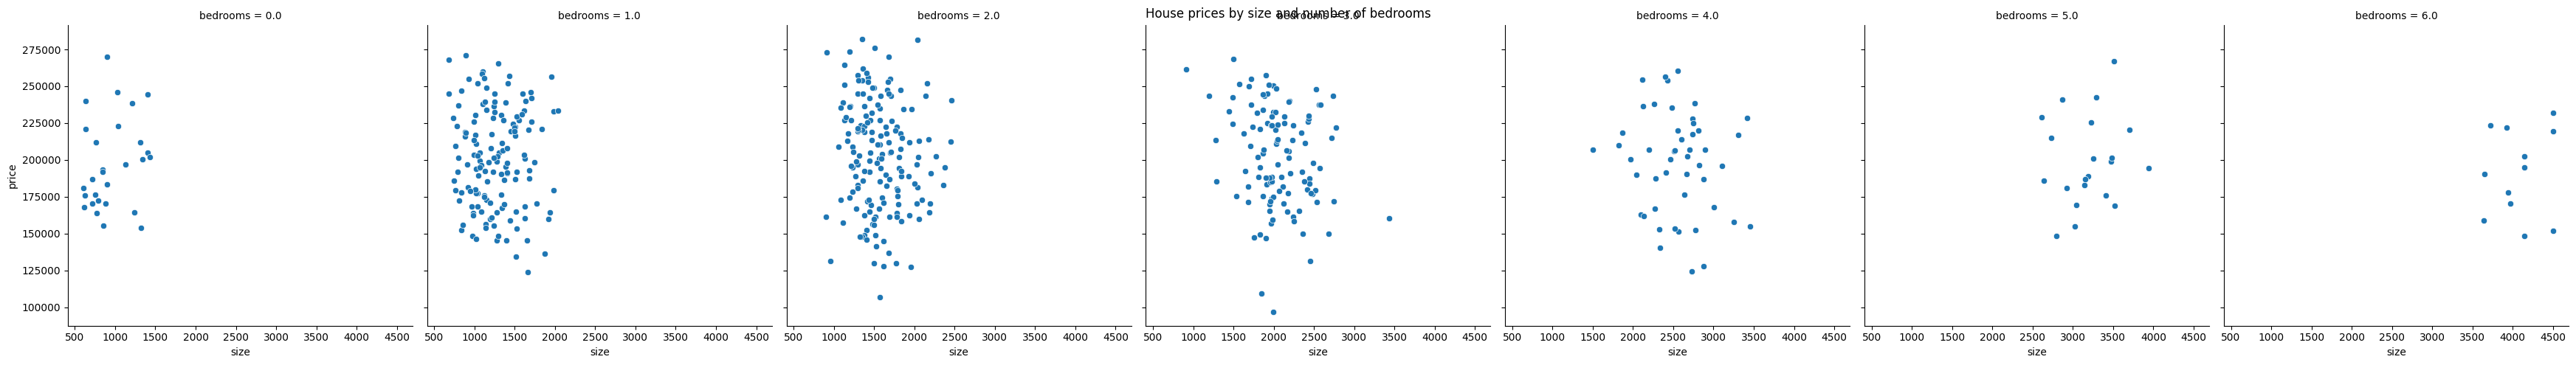

In [ ]:
sns.relplot(data= df, x= "size", y= "price", col= "bedrooms", kind= "scatter")
plt.suptitle("House prices by size and number of bedrooms")

Does the relationship between size and price look similar across bedroom counts?

I would say the relationship does look similar across the bedroom counts. The more bedrooms there are the larger the size gets (obviously). However, when looking at the prices all the data points seem to be spread out evently between higher and lower prices despite the number of bedrooms.

---

## C. Distribution and Categorical Plots
1. Create a histogram of price.
2. Create a density plot of price.
3. Create a boxplot of price by neighborhood.

Text(0, 0.5, 'Number of Houses')

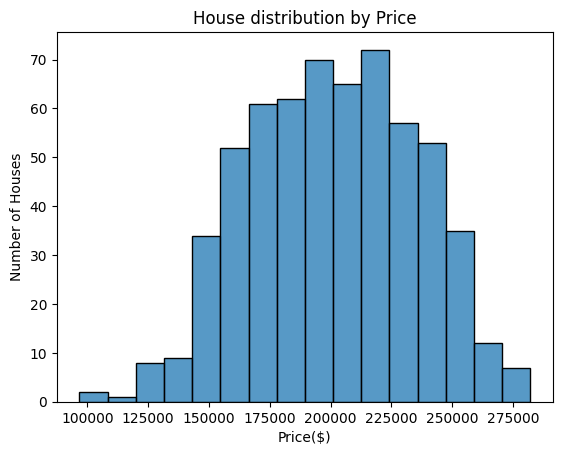

In [ ]:
sns.histplot(data= df, x= "price")
plt.title("House distribution by Price")
plt.xlabel("Price($)")
plt.ylabel("Number of Houses")

Text(0, 0.5, 'Density')

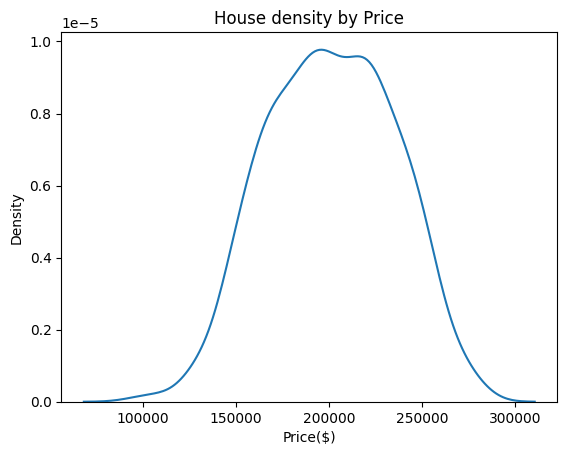

In [ ]:
sns.kdeplot(data= df, x= "price")
plt.title("House density by Price")
plt.xlabel("Price($)")
plt.ylabel("Density")

Text(0, 0.5, 'Price($)')

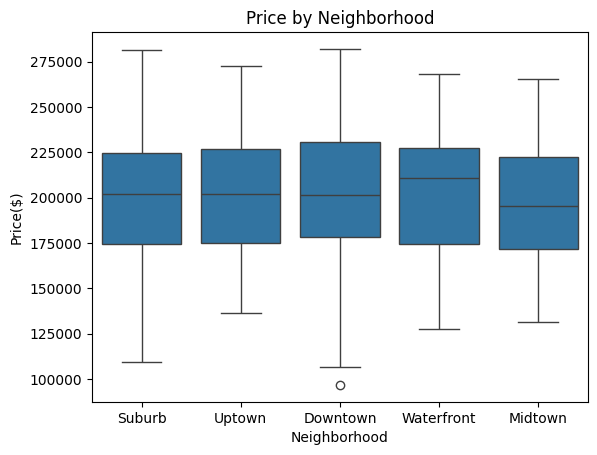

In [ ]:
sns.boxplot(data= df, x= "neighborhood", y= "price")
plt.title("Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price($)")

- Do neighborhoods differ systematically in price?
- What visual evidence supports your claim?

The median price for four of the neighborhoods (excluding Waterfront) is around $200000. Downtown and Suburb have the widest spread with Downtown having one outlier. Waterfront also seems to be skewed to the left. Overall I would say the price between neighborhoods is roughly similar to each other.

---

## Part II -- Linear Regression for Inference (30 pts)
## A. Multiple Regression (R → Python)
In R, the model would be:

lm(price ~ size + bedrooms + neighborhood, data = df)
In Python:

1. Fit the equivalent model using statsmodels.
2. Report:
    - Coefficient estimates
    - Standard errors
    - R²

In [ ]:
model = smf.ols("price ~ size + bedrooms + neighborhood", data= df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Sat, 07 Mar 2026   Prob (F-statistic):              0.190
Time:                        06:22:57   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
neighborhood[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
neighborhood[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
neighborhood[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
neighborhood[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                         -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                    4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. Interpret the coefficient on size, explicitly stating what is being held constant.
2. Is size statistically significant? How do you know?
3. What does R² tell us in this context?

Looking at the coefficient for size while keeping the number of bedrooms and neighborhoods constant we can see that for every sqft added to a house the price decreases by about $10.94.
Size is statistically significant as the p-value is 0.010 which is less than 0.05.
The R² is 0.017 which tells us that this model and its predictors explains about 1.7% of the variance of house prices. This shows us that this model isn't a very good predictor for house prices.

---

## Part III -- Prediction Workflow (20 pts)
Now switch goals: Prediction instead of explanation

1. Split the data into training and test sets.
2. Fit linear regression using scikit-learn.
3. Compute:
   - RMSE (on test set)
   - R² (on test set)

In [7]:
df= df.dropna()
df.isna().sum()

,0
listing_id,0
price,0
size,0
bedrooms,0
neighborhood,0
type,0


In [19]:
X = df[["size", "bedrooms", "neighborhood"]]

y = df["price"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,
    random_state=30)

In [25]:
model= LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(rmse)
print(r2)

36790.16202375099
-0.01806791194992874


- Why does scikit-learn not report p-values?
- Which workflow would you use for:
    - Explanation?
    - Prediction?
- Why are these different goals?

Scikit-learn is designed for prediction and not for statistical inference like statsmodels. For explanation you would use statsmodels because it gives you information such as the p-value and coefficients. For prediction you would use scikit-learn. Explanation focuses on the relatioships between variables while prediction focuses on predicting future data.

---
## Part IV -- Integrated Thinking (10 pts)
Create one polished figure that:

- Shows size vs price
- Colors by neighborhood
- Includes a regression line
- Has professional formatting

Text(0, 0.5, 'Price ($)')

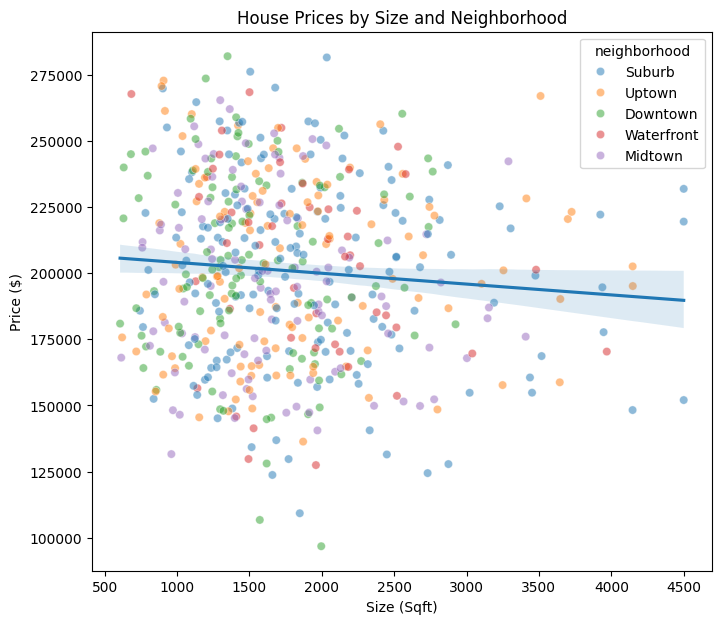

In [ ]:
plt.figure(figsize= (8,7))
sns.scatterplot(data= df, x= "size", y= "price", hue= "neighborhood", alpha= 0.5)
sns.regplot(data= df, x= "size", y= "price", scatter= False)
plt.title("House Prices by Size and Neighborhood")
plt.xlabel("Size (Sqft)")
plt.ylabel("Price ($)")

- Does the regression model match what you visually observed?
- Did the visualization help you anticipate the model results?

The regression model does match the scatterplot. We can notice the regression line shows a decrease in price as size increases. This is what the regression model showed us happened with the coefficient of size.